# Advances in Complex Systems: Inequality, 29 June – 3 July, 2026
## Italian Socio-Economic & Geospatial Data

**Exploratory analysis + geographic analysis (income & real-estate prices).**

This notebook documents, loads, and explores a collection of Italian open data focused on
**Lombardy / Milan / Como**, then performs a geographic analysis joining income and real-estate
prices onto administrative boundaries with **GeoPandas**.

The analysis can run for all of Italy or zoom to a region / province (see the *Parameters* cell)

To run this notebook it is require to install the packages described in the file **requirements.txt**
See SETUP.md

## 1. What is in the dataset

The data lives under `data/`. It combines administrative geometry, postal-code zones, real-estate
market values, and personal-income tax statistics — all linkable by Italian municipality.

| Layer | Path | Type / CRS | Key fields |
|---|---|---|---|
| Municipal boundaries (ISTAT 2020, **Lombardy only**, ~1,506 comuni) | `data/limiti_comunali_2020.geojson` | GeoJSON polygons | `belfiore`, `istat`, `nome_com`, `nome_reg`, `sig_pro` |
| Census sections (Lombardy) | `data/census_lom.gpkg` | GeoPackage polygons | — |
| Eurostat LAU 2021 (EU) | `data/ref-lau-2021-01m.shp/` | Shapefile, EPSG:3035 | `GISCO_ID`, `LAU_NAME`, `POP_2021`, `AREA_KM2` |
| CAP zones (national) | `data/atlante_istat/CodAvvPostale/` | Shapefile, ED50/UTM32N | `CAP` |
| CAP zones (Milan, with usage) | `data/banchedati-cap-zone-demo-database/CAPZONE_Milano.shp` | Shapefile, WGS84 | `CAP`, `COMUNE`, `ABITAZIONI`, `NEGOZI`, `UFFICI` |
| CAP points (Lombardy 2020) | `data/pointcaps_lom2020/` | Shapefile, ETRS89 | `POSTCODE`, `GISCO_ID`, `FUA_ID` |
| OMI real-estate quotations (**Lombardy**) | `data/omi/{2011,2021}/quotazioni.csv` | CSV (`;`) | `Comune_amm`, `Zona`, `Compr_min/max`, `Loc_min/max` |
| OMI zone polygons | `data/omi/{2011,2021}/zone/*.kml` | KML (~7.4k–7.9k zones) | — |
| Income (IRPEF, MEF) — municipal | `data/Redditi/{year}/comunali.csv` | CSV (`;`) | `Codice catastale`, `Codice Istat Comune`, `Reddito imponibile - *` |
| Income — sub-municipal (by CAP) | `data/Redditi/{year}/subcomunali.csv` | CSV (`;`) | `CAP`, `Codice Istat Comune`, income columns |

> **Coverage asymmetry (read before mapping):** the *income* tables are **national** (all 22 regions,
> ~7,900 comuni), but the only municipal **geometry** here — `limiti_comunali_2020.geojson` — plus the
> OMI prices and the census layer cover **Lombardy only**. So the *income EDA* can target any region
> via the `REGION` parameter, while **maps are inherently Lombardy** (zoom within it with
> `FOCUS_PROVINCE`, e.g. Como `CO` or Milan `MI`). National mapping would require the EU LAU layer.

**Sources:** ISTAT (boundaries, CAP), Eurostat GISCO (LAU), Agenzia delle Entrate — *OMI*
(real-estate quotations), MEF — Dipartimento delle Finanze (*Redditi* IRPEF declarations).

**The unifying join key is the *Belfiore* cadastral code** (e.g. `A001`), which appears as:
`Codice catastale` (Redditi) ↔ `Comune_amm` (OMI) ↔ `belfiore` (boundaries). We use it to merge the
three sources at municipality level.

**Format notes:** CSVs are `;`-separated with Italian column names; OMI rent values use a decimal
comma (`12,8`); files carry a trailing empty column. CRS differ across layers, so we reproject to a
common CRS before any spatial operation.


# Notebook

In [21]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import expon, pareto, kstest

DATA_DIR = Path("data")

# Error when changing year for income, check later maybe
YEAR      = 2022          # Redditi (income) year: 2011, 2015, 2019, 2020, 2021, 2022
OMI_YEAR  = 2021          # OMI real-estate year: 2011 or 2021

# Geographic scope.
#  - REGION drives the (national) income EDA: "LOMBARDIA", "LAZIO", ... or None for all Italy.
#  - Maps use the boundary geometry, which covers LOMBARDIA only, so spatial sections always
#    render Lombardy; use FOCUS_PROVINCE to zoom inside it.
REGION          = "LOMBARDIA"   # income-EDA scope
FOCUS_PROVINCE  = "CO"          # map zoom within Lombardy: "CO" (Como), "MI" (Milano), ... or None

COMMON_CRS = 3857         # Web Mercator, lets us add contextily basemaps
ADD_BASEMAP = True        # set False to skip basemap tiles (e.g. offline)

print(f"Income year={YEAR}  OMI year={OMI_YEAR}  region={REGION}  focus={FOCUS_PROVINCE}")

try:
    import contextily as cx
    HAS_CTX = True
except Exception:
    HAS_CTX = False
    ADD_BASEMAP = False

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)


def read_istat_csv(path, **kwargs):
    # Read a ;-separated Italian-locale CSV (decimals as comma); try utf-8 then latin1,
    # and drop the trailing empty column these files carry.
    for enc in ("utf-8", "latin1"):
        try:
            df = pd.read_csv(path, sep=";", decimal=",", encoding=enc,
                             low_memory=False, **kwargs)
            break
        except UnicodeDecodeError:
            continue
    # drop trailing unnamed/empty column(s)
    df = df.loc[:, ~df.columns.str.match(r"^Unnamed|^\s*$")]
    df.columns = df.columns.str.strip()
    return df


def belfiore(series):
    # Normalize a Belfiore cadastral code column for joining.
    return series.astype(str).str.strip().str.upper()

# --- Income (Redditi) at municipal level ---
red_path = DATA_DIR / "Redditi" / str(YEAR) / "comunali.csv"
redditi = read_istat_csv(red_path)
print("Redditi comunali:", redditi.shape)

# Column names are long; map the few we need to short handles.
COL_TAXPAYERS = "Numero contribuenti"
COL_INCOME    = "Reddito imponibile - Ammontare in euro"
COL_ISTAT     = "Codice Istat Comune"
COL_CAT       = "Codice catastale"
COL_PROV      = "Sigla Provincia"
COL_REGION    = "Regione"
COL_COMUNE    = "Denominazione Comune"

# Average taxable income per taxpayer (euro) — our headline income indicator.
redditi["avg_income"] = redditi[COL_INCOME] / redditi[COL_TAXPAYERS]
redditi["belfiore"]   = belfiore(redditi[COL_CAT])

# Optional region filter (income table uses full region names in `Regione`).
if REGION is not None:
    red_view = redditi[redditi[COL_REGION].str.upper() == REGION.upper()].copy()
else:
    red_view = redditi.copy()
print(f"Municipalities in scope: {len(red_view)} (of {len(redditi)} national)")
red_view[[COL_COMUNE, COL_PROV, COL_REGION, COL_TAXPAYERS, "avg_income"]].head()

# --- Real-estate (OMI) quotations ---
omi_path = DATA_DIR / "omi" / str(OMI_YEAR) / "quotazioni.csv"
omi = read_istat_csv(omi_path)
# print("OMI quotazioni:", omi.shape)
# omi[["Regione", "Prov", "Comune_descrizione", "Zona", "Descr_Tipologia",
     # "Compr_min", "Compr_max", "Loc_min", "Loc_max"]].head(3)

Income year=2022  OMI year=2021  region=LOMBARDIA  focus=CO
Redditi comunali: (7901, 50)
Municipalities in scope: 1503 (of 7901 national)


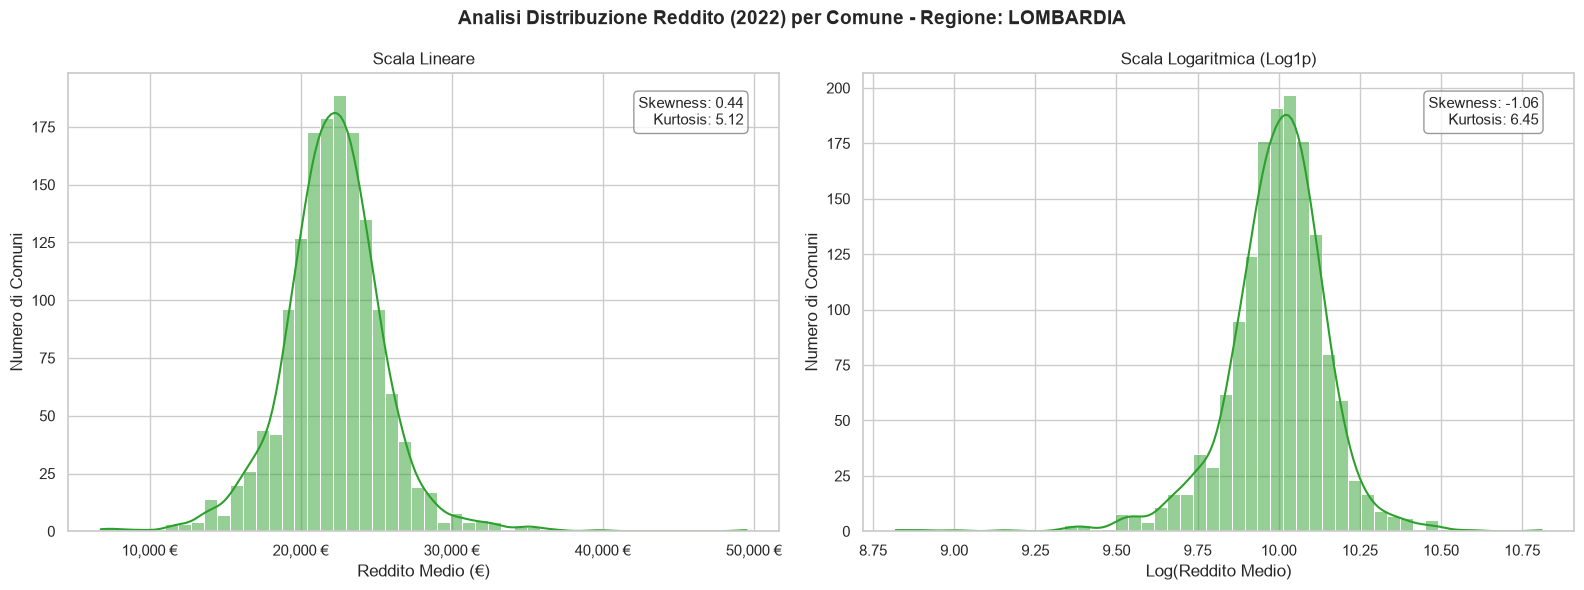

In [ ]:
def plot_reddito(df, scala="entrambe"):
    """
    Plotta la distribuzione del reddito medio dei singoli comuni.
    Parametro 'scala': "lineare", "log", "entrambe"
    """
    # Verifichiamo che il dataframe non sia vuoto
    if df.empty:
        print("Il dataframe è vuoto. Impossibile plottare.")
        return

    color_income = "#2ca02c" # Verde
    
    # Funzione di supporto per calcolare e aggiungere il box con le statistiche
    def add_stats_box(ax, data_series):
        # Calcolo Skewness e Curtosi ignorando eventuali NaN
        skewness = data_series.skew()
        kurtosis = data_series.kurt()
        
        # Testo da mostrare
        testo = f"Skewness: {skewness:.2f}\nKurtosis: {kurtosis:.2f}"
        
        # Stile del box
        props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
        
        # Posizionamento (0.95, 0.95 significa in alto a destra)
        ax.text(0.95, 0.95, testo, transform=ax.transAxes, fontsize=11,
                verticalalignment='top', horizontalalignment='right', bbox=props)

    if scala == "lineare":
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.histplot(data=df, x="avg_income", kde=True, color=color_income, bins=50, ax=ax)
        
        ax.set_title(f"Distribuzione Reddito Medio Comunale ({YEAR}) - Scala Lineare")
        ax.set_xlabel("Reddito Medio per Contribuente (€)")
        ax.set_ylabel("Numero di Comuni")
        ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f} €'))
        
        # Aggiungo le statistiche
        add_stats_box(ax, df["avg_income"])
        
    elif scala == "log":
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Usiamo log1p per sicurezza matematica
        df["log_avg_income"] = np.log1p(df["avg_income"])
        sns.histplot(data=df, x="log_avg_income", kde=True, color=color_income, bins=50, ax=ax)
        
        ax.set_title(f"Distribuzione Reddito Medio Comunale ({YEAR}) - Scala Logaritmica")
        ax.set_xlabel("Log(Reddito Medio)")
        ax.set_ylabel("Numero di Comuni")
        
        # Aggiungo le statistiche
        add_stats_box(ax, df["log_avg_income"])
        
    elif scala == "entrambe":
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(f"Analisi Distribuzione Reddito ({YEAR}) per Comune - Regione: {REGION}", fontsize=14, fontweight='bold')
        
        # --- Plot Lineare ---
        sns.histplot(data=df, x="avg_income", kde=True, color=color_income, bins=50, ax=axes[0])
        axes[0].set_title("Scala Lineare")
        axes[0].set_xlabel("Reddito Medio (€)")
        axes[0].set_ylabel("Numero di Comuni")
        axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f} €'))
        add_stats_box(axes[0], df["avg_income"])
        
        # --- Plot Logaritmico ---
        df["log_avg_income"] = np.log1p(df["avg_income"])
        sns.histplot(data=df, x="log_avg_income", kde=True, color=color_income, bins=50, ax=axes[1])
        axes[1].set_title("Scala Logaritmica (Log1p)")
        axes[1].set_xlabel("Log(Reddito Medio)")
        axes[1].set_ylabel("Numero di Comuni")
        add_stats_box(axes[1], df["log_avg_income"])
        
    else:
        print("Parametro 'scala' non valido. Scegli tra 'lineare', 'log', 'entrambe'.")
        return

    plt.tight_layout()
    plt.show()

# Esecuzione della funzione
plot_reddito(red_view, scala="entrambe")

In [15]:
def esplora_omi_comune(omi_df, nome_comune):
    """
    Filtra il dataset OMI grezzo per un singolo comune e ne mostra 
    il dettaglio di Zone, Tipologie immobiliari e Prezzi.
    """
    # Filtriamo il dataframe ignorando maiuscole/minuscole
    df_comune = omi_df[omi_df["Comune_descrizione"].astype(str).str.upper() == nome_comune.upper()].copy()
    
    if df_comune.empty:
        print(f"Nessun dato OMI trovato per il comune: {nome_comune}")
        # Suggerimento per il debug: stampa i primi 5 comuni disponibili
        print("Esempi di comuni disponibili:", omi_df["Comune_descrizione"].dropna().unique()[:5])
        return
    
    # 1. Panoramica Generale
    print(f"{"="*50}")
    print(f" DATI OMI PER: {nome_comune.upper()}")
    print(f"{"="*50}")
    print(f"Numero totale di record (Zone x Tipologie): {len(df_comune)}")
    
    zone_presenti = df_comune['Zona'].unique()
    print(f"\nNumero di micro-zone OMI: {len(zone_presenti)}")
    print(f"Codici Zona: {zone_presenti}")
    
    tipologie = df_comune['Descr_Tipologia'].unique()
    print(f"\nTipologie di immobili tracciate ({len(tipologie)}):")
    for tipo in tipologie:
        print(f"  - {tipo}")
        
    print("\n--- DETTAGLIO QUOTAZIONI ---")
    # 2. Tabella di dettaglio ordinata
    colonne_utili = [
        "Zona", "Descr_Tipologia", 
        "Compr_min", "Compr_max", 
        "Loc_min", "Loc_max"
    ]
    
    dettaglio = df_comune[colonne_utili].sort_values(by=["Zona", "Descr_Tipologia"])
    
    # Se sei su Jupyter usa display(), altrimenti print()
    try:
        display(dettaglio)
    except NameError:
        print(dettaglio.to_string(index=False))

# --- ESEMPI DI UTILIZZO ---
# Puoi testarlo con qualsiasi comune lombardo. Passa il dataset 'omi' intero.
esplora_omi_comune(omi, "MILANO")
# esplora_omi_comune(omi, "CERNOBBIO")
# esplora_omi_comune(omi, "TREMEZZINA")

 DATI OMI PER: MILANO
Numero totale di record (Zone x Tipologie): 486

Numero di micro-zone OMI: 40
Codici Zona: <StringArray>
['B12', 'B13', 'B15', 'B16', 'B17', 'B18', 'B19', 'B20', 'B21', 'C12', 'C13',
 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'D10', 'D12', 'D13', 'D15',
 'D16', 'D18', 'D20', 'D21', 'D24', 'D25', 'D28', 'D30', 'D31', 'D32', 'D33',
 'D34', 'D35', 'D36',  'E5',  'E6',  'E7',  'E8']
Length: 40, dtype: str

Tipologie di immobili tracciate (12):
  - Abitazioni civili
  - Abitazioni di tipo economico
  - Abitazioni signorili
  - Box
  - Magazzini
  - Negozi
  - Uffici
  - Uffici strutturati
  - Laboratori
  - Capannoni industriali
  - Capannoni tipici
  - Ville e Villini

--- DETTAGLIO QUOTAZIONI ---


,Zona,Descr_Tipologia,Compr_min,Compr_max,Loc_min,Loc_max
14438,B12,Abitazioni civili,9000.0,12400.0,27.0,36.0
14439,B12,Abitazioni civili,7200.0,8900.0,22.0,27.0
14440,B12,Abitazioni di tipo economico,6400.0,7400.0,17.5,22.5
14441,B12,Abitazioni di tipo economico,7400.0,8800.0,23.0,28.0
14442,B12,Abitazioni signorili,10800.0,14300.0,35.5,46.0
...,...,...,...,...,...,...
14923,E8,Laboratori,650.0,850.0,3.9,5.2
14917,E8,Magazzini,400.0,600.0,2.2,3.4
14918,E8,Negozi,900.0,1550.0,4.2,7.8
14919,E8,Uffici,1100.0,1600.0,5.7,8.3


Comuni immobiliari calcolati in scope: 1505


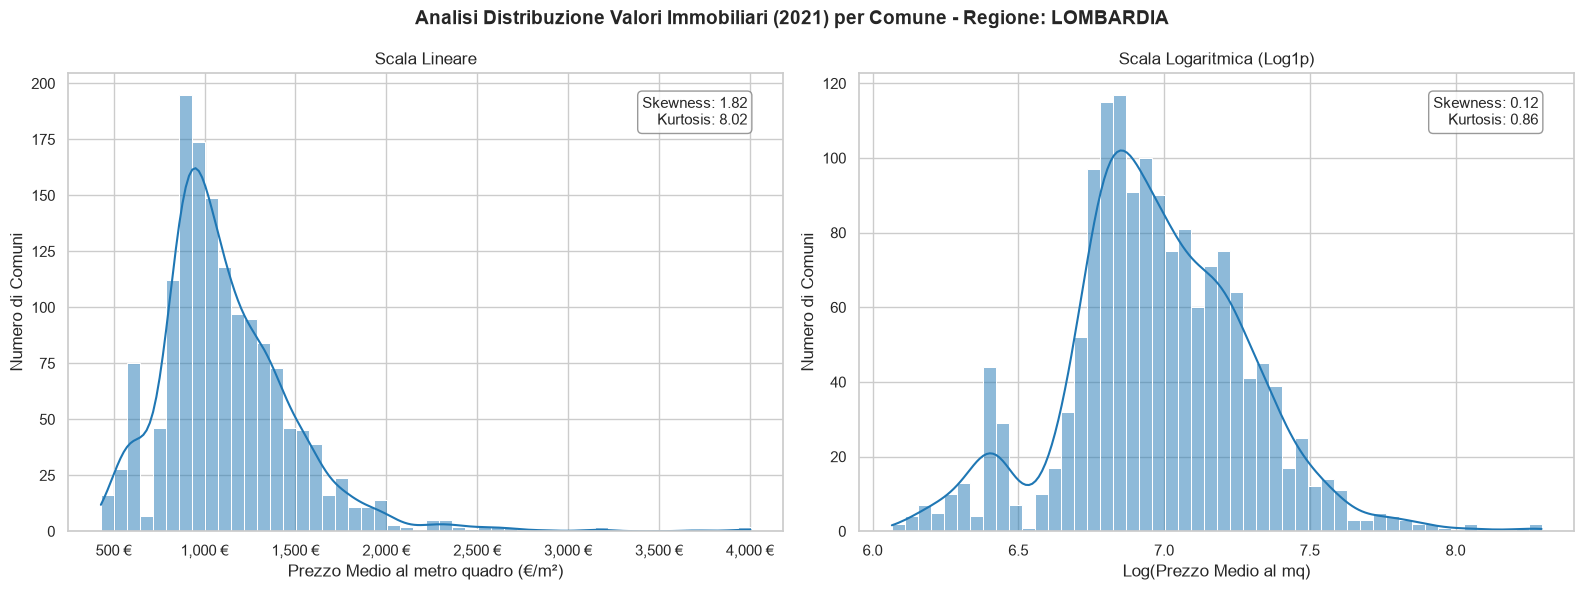

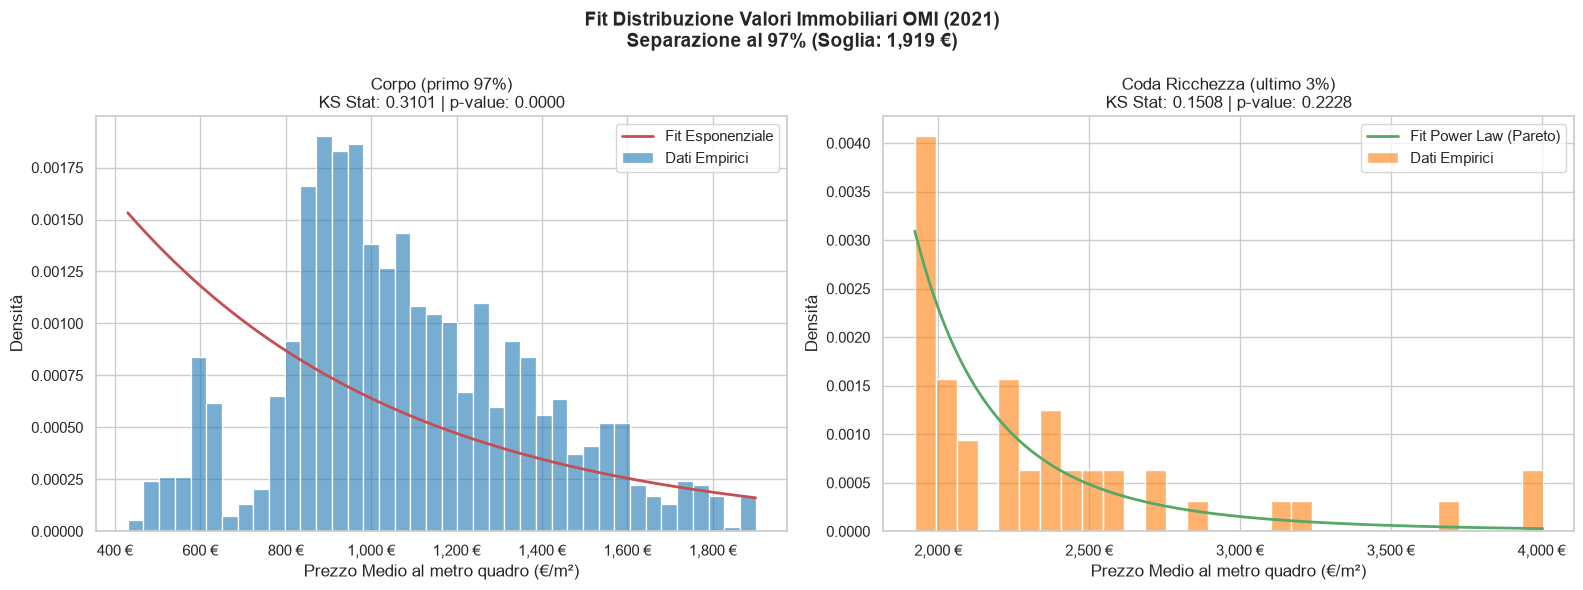


 RISULTATI FIT STATISTICO E TEST KOLMOGOROV-SMIRNOV
Soglia di separazione (Percentile 97%): 1,919.26 €/m²
Comuni nel corpo: 1459 | Comuni nella coda: 46
-----------------------------------------------------------------
1. CORPO (Esponenziale)
   - Parametri Fit: loc=430.0000, scale=652.5299
   - Test KS Statistica: 0.3101
   - Test KS P-Value:    4.1263e-125
   - ESITO TEST (α=0.05): RIFIUTATO  (I dati si discostano dalla teorica)
-----------------------------------------------------------------
2. CODA (Power Law / Pareto)
   - Parametri Fit: shape(b)=3.6136, loc=753.9180, scale=1167.9570
   - Test KS Statistica: 0.1508
   - Test KS P-Value:    2.2282e-01
   - ESITO TEST (α=0.05): ACCETTATO  (I dati seguono la legge di potenza)



In [23]:
# --- 1. PREPARAZIONE DATI OMI (Come e Perché) ---

# Assicuriamoci che i prezzi siano formattati come numeri
omi["Compr_min"] = pd.to_numeric(omi["Compr_min"], errors="coerce")
omi["Compr_max"] = pd.to_numeric(omi["Compr_max"], errors="coerce")

# Filtriamo per la Regione scelta all'inizio (se REGION è impostato)
if REGION is not None:
    omi_view = omi[omi["Regione"].astype(str).str.upper() == REGION.upper()].copy()
else:
    omi_view = omi.copy()

# FILTRO TIPOLOGIA: Teniamo solo la componente residenziale
omi_residenziale = omi_view[omi_view["Descr_Tipologia"].astype(str).str.contains("abitazion|vill", case=False, na=False)].copy()

# CALCOLO: Punto medio tra minimo e massimo per ogni zona OMI
omi_residenziale["prezzo_mq_zonale"] = omi_residenziale[["Compr_min", "Compr_max"]].mean(axis=1)

# AGGREGAZIONE: Calcoliamo un unico valore medio al mq per intero comune
omi_comuni = omi_residenziale.groupby("Comune_descrizione")["prezzo_mq_zonale"].mean().reset_index()
omi_comuni.rename(columns={"prezzo_mq_zonale": "prezzo_mq_medio"}, inplace=True)
omi_comuni = omi_comuni.dropna(subset=["prezzo_mq_medio"]) # Pulizia eventuali valori mancanti

print(f"Comuni immobiliari calcolati in scope: {len(omi_comuni)}")


# --- 2. FUNZIONE DI PLOT ---

def plot_real_estate(df, scala="entrambe"):
    """
    Plotta la distribuzione dei valori immobiliari (OMI) medi per comune.
    Parametro 'scala': "lineare", "log", "entrambe"
    """
    if df.empty:
        print("Il dataframe è vuoto. Impossibile plottare.")
        return

    color_omi = "#1f77b4" # Blu per differenziarlo dai redditi
    
    def add_stats_box(ax, data_series):
        # Calcolo Skewness e Curtosi
        skewness = data_series.skew()
        kurtosis = data_series.kurt()
        testo = f"Skewness: {skewness:.2f}\nKurtosis: {kurtosis:.2f}"
        props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
        ax.text(0.95, 0.95, testo, transform=ax.transAxes, fontsize=11,
                verticalalignment='top', horizontalalignment='right', bbox=props)

    if scala == "lineare":
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.histplot(data=df, x="prezzo_mq_medio", kde=True, color=color_omi, bins=50, ax=ax)
        
        ax.set_title(f"Distribuzione Valore Immobiliare Comunale ({OMI_YEAR}) - Scala Lineare")
        ax.set_xlabel("Prezzo Medio al metro quadro (€/m²)")
        ax.set_ylabel("Numero di Comuni")
        ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f} €'))
        add_stats_box(ax, df["prezzo_mq_medio"])
        
    elif scala == "log":
        fig, ax = plt.subplots(figsize=(10, 6))
        df["log_prezzo_mq"] = np.log1p(df["prezzo_mq_medio"])
        sns.histplot(data=df, x="log_prezzo_mq", kde=True, color=color_omi, bins=50, ax=ax)
        
        ax.set_title(f"Distribuzione Valore Immobiliare Comunale ({OMI_YEAR}) - Scala Logaritmica")
        ax.set_xlabel("Log(Prezzo Medio al mq)")
        ax.set_ylabel("Numero di Comuni")
        add_stats_box(ax, df["log_prezzo_mq"])
        
    elif scala == "entrambe":
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(f"Analisi Distribuzione Valori Immobiliari ({OMI_YEAR}) per Comune - Regione: {REGION}", fontsize=14, fontweight='bold')
        
        # Plot Lineare
        sns.histplot(data=df, x="prezzo_mq_medio", kde=True, color=color_omi, bins=50, ax=axes[0])
        axes[0].set_title("Scala Lineare")
        axes[0].set_xlabel("Prezzo Medio al metro quadro (€/m²)")
        axes[0].set_ylabel("Numero di Comuni")
        axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f} €'))
        add_stats_box(axes[0], df["prezzo_mq_medio"])
        
        # Plot Logaritmico
        df["log_prezzo_mq"] = np.log1p(df["prezzo_mq_medio"])
        sns.histplot(data=df, x="log_prezzo_mq", kde=True, color=color_omi, bins=50, ax=axes[1])
        axes[1].set_title("Scala Logaritmica (Log1p)")
        axes[1].set_xlabel("Log(Prezzo Medio al mq)")
        axes[1].set_ylabel("Numero di Comuni")
        add_stats_box(axes[1], df["log_prezzo_mq"])
        
    else:
        print("Parametro 'scala' non valido. Scegli tra 'lineare', 'log', 'entrambe'.")
        return

    plt.tight_layout()
    plt.show()

# Esecuzione della funzione sul dataframe preparato
plot_real_estate(omi_comuni, scala="entrambe")

# --- 3. ANALISI STATISTICA: CORPO vs CODA (Fit e Test KS) ---

def fit_and_plot_split_distribution(df, split_pct=0.97):
    """
    Separa il dataset al percentile specificato.
    Esegue un fit Esponenziale sul primo (es. 97%) e un fit Power Law (Pareto) sulla coda (es. 3%).
    Effettua il test di Kolmogorov-Smirnov per valutare la bontà del fit e plotta in scala lineare.
    """
    if df.empty:
        print("Il dataframe è vuoto. Impossibile analizzare.")
        return

    # Estraiamo la serie dei dati
    dati = df["prezzo_mq_medio"].dropna()
    
    # 1. Calcolo della soglia e separazione
    threshold = dati.quantile(split_pct)
    data_body = dati[dati <= threshold]
    data_tail = dati[dati > threshold]
    
    # 2. Fit ed Esponenziale (Corpo)
    # loc = shift (spostamento sull'asse x), scale = lambda inversa
    loc_exp, scale_exp = expon.fit(data_body)
    ks_stat_exp, p_val_exp = kstest(data_body, 'expon', args=(loc_exp, scale_exp))
    
    # 3. Fit e Power Law / Pareto (Coda)
    # b = parametro di forma (shape), loc = shift, scale = parametro di scala
    b_par, loc_par, scale_par = pareto.fit(data_tail)
    ks_stat_par, p_val_par = kstest(data_tail, 'pareto', args=(b_par, loc_par, scale_par))
    
    # --- 4. PLOT IN SCALA LINEARE ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    titolo_globale = (f"Fit Distribuzione Valori Immobiliari OMI ({OMI_YEAR})\n"
                      f"Separazione al {split_pct*100:.0f}% (Soglia: {threshold:,.0f} €)")
    fig.suptitle(titolo_globale, fontsize=14, fontweight='bold')
    
    # Grafico 1: Corpo (97%)
    ax1 = axes[0]
    sns.histplot(data_body, stat='density', bins=40, color="#1f77b4", alpha=0.6, ax=ax1, label='Dati Empirici')
    
    # Curva Esponenziale
    x_exp = np.linspace(data_body.min(), data_body.max(), 200)
    y_exp = expon.pdf(x_exp, loc_exp, scale_exp)
    ax1.plot(x_exp, y_exp, 'r-', lw=2, label='Fit Esponenziale')
    
    ax1.set_title(f"Corpo (primo {split_pct*100:.0f}%)\nKS Stat: {ks_stat_exp:.4f} | p-value: {p_val_exp:.4f}")
    ax1.set_xlabel("Prezzo Medio al metro quadro (€/m²)")
    ax1.set_ylabel("Densità")
    ax1.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f} €'))
    ax1.legend()
    
    # Grafico 2: Coda (3%)
    ax2 = axes[1]
    sns.histplot(data_tail, stat='density', bins=30, color="#ff7f0e", alpha=0.6, ax=ax2, label='Dati Empirici')
    
    # Curva Pareto (Power Law)
    x_par = np.linspace(data_tail.min(), data_tail.max(), 200)
    y_par = pareto.pdf(x_par, b_par, loc_par, scale_par)
    ax2.plot(x_par, y_par, 'g-', lw=2, label='Fit Power Law (Pareto)')
    
    ax2.set_title(f"Coda Ricchezza (ultimo {(1-split_pct)*100:.0f}%)\nKS Stat: {ks_stat_par:.4f} | p-value: {p_val_par:.4f}")
    ax2.set_xlabel("Prezzo Medio al metro quadro (€/m²)")
    ax2.set_ylabel("Densità")
    ax2.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f} €'))
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

    # --- 5. STAMPA DEI RISULTATI IN CONSOLE ---
    # Interpretazione del p-value basata sul livello di significatività standard alpha = 0.05
    # H0: I dati seguono la distribuzione teorica. Se p < 0.05, rifiutiamo H0.
    esito_exp = "ACCETTATO  (I dati seguono la forma esponenziale)" if p_val_exp >= 0.05 else "RIFIUTATO  (I dati si discostano dalla teorica)"
    esito_par = "ACCETTATO  (I dati seguono la legge di potenza)" if p_val_par >= 0.05 else "RIFIUTATO  (I dati si discostano dalla teorica)"

    print("\n" + "="*65)
    print(" RISULTATI FIT STATISTICO E TEST KOLMOGOROV-SMIRNOV")
    print("="*65)
    print(f"Soglia di separazione (Percentile {split_pct*100:.0f}%): {threshold:,.2f} €/m²")
    print(f"Comuni nel corpo: {len(data_body)} | Comuni nella coda: {len(data_tail)}")
    print("-" * 65)
    print("1. CORPO (Esponenziale)")
    print(f"   - Parametri Fit: loc={loc_exp:.4f}, scale={scale_exp:.4f}")
    print(f"   - Test KS Statistica: {ks_stat_exp:.4f}")
    print(f"   - Test KS P-Value:    {p_val_exp:.4e}")
    print(f"   - ESITO TEST (α=0.05): {esito_exp}")
    print("-" * 65)
    print("2. CODA (Power Law / Pareto)")
    print(f"   - Parametri Fit: shape(b)={b_par:.4f}, loc={loc_par:.4f}, scale={scale_par:.4f}")
    print(f"   - Test KS Statistica: {ks_stat_par:.4f}")
    print(f"   - Test KS P-Value:    {p_val_par:.4e}")
    print(f"   - ESITO TEST (α=0.05): {esito_par}")
    print("="*65 + "\n")

# Esecuzione della nuova funzione
fit_and_plot_split_distribution(omi_comuni, split_pct=0.97)

## 5. Exploratory analysis — income (non-spatial)

Distribution and ranking of **average taxable income per taxpayer** across municipalities in scope.

count     1503.0
mean     22181.0
std       3361.0
min       6766.0
25%      20390.0
50%      22206.0
75%      23956.0
max      49524.0
Name: avg_income, dtype: float64


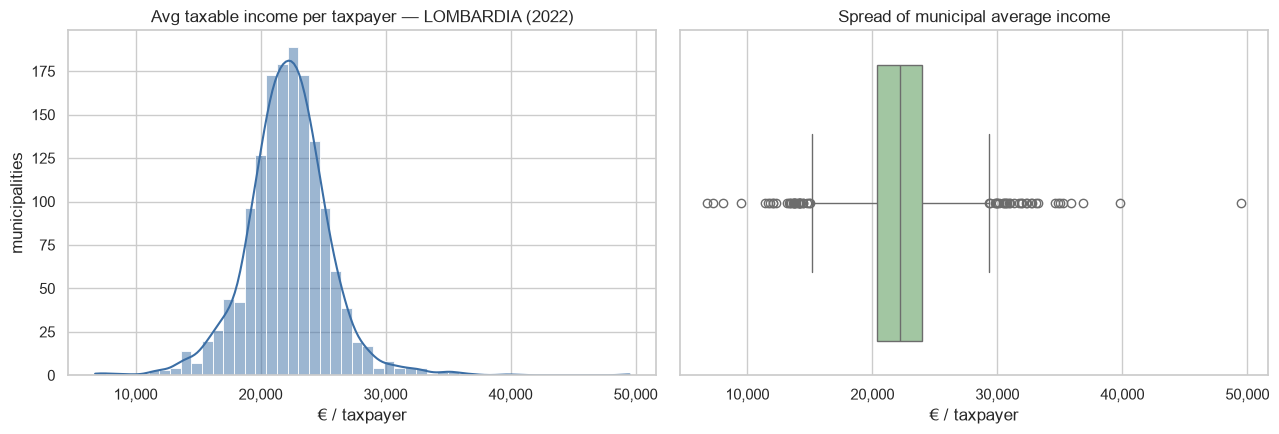

In [7]:
desc = red_view["avg_income"].describe()
print(desc.round(0))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(red_view["avg_income"], bins=50, kde=True, ax=axes[0], color="#3b6ea5")
axes[0].set(title=f"Avg taxable income per taxpayer — {REGION or 'Italy'} ({YEAR})",
            xlabel="€ / taxpayer", ylabel="municipalities")
axes[0].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

sns.boxplot(x=red_view["avg_income"], ax=axes[1], color="#9ccc9c")
axes[1].set(title="Spread of municipal average income", xlabel="€ / taxpayer")
axes[1].xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

In [8]:
# Top & bottom municipalities by average income (within scope).
cols = [COL_COMUNE, COL_PROV, COL_TAXPAYERS, "avg_income"]
top = red_view.nlargest(10, "avg_income")[cols]
bot = red_view[red_view[COL_TAXPAYERS] > 500].nsmallest(10, "avg_income")[cols]
print("Top 10 by avg income:"); display(top.round(0))
print("\nBottom 10 (municipalities with >500 taxpayers):"); display(bot.round(0))

Top 10 by avg income:


,Denominazione Comune,Sigla Provincia,Numero contribuenti,avg_income
557,BASIGLIO,MI,5704,49524.0
2457,CUSAGO,MI,3435,39814.0
7040,TORRE D'ISOLA,PV,1852,36841.0
6516,SEGRATE,MI,27611,35866.0
3950,MILANO,MI,1034105,35282.0
4740,PADENGHE SUL GARDA,BS,3561,35041.0
316,ARESE,MI,14713,34879.0
2939,GALLIATE LOMBARDO,VA,750,34640.0
5962,SAN DONATO MILANESE,MI,24162,33213.0
7362,VEDANO AL LAMBRO,MB,5781,33061.0



Bottom 10 (municipalities with >500 taxpayers):


,Denominazione Comune,Sigla Provincia,Numero contribuenti,avg_income
2250,VALSOLDA,CO,901,11653.0
7505,VILLA DI CHIAVENNA,SO,669,12040.0
3423,LAVENA PONTE TRESA,VA,3146,12042.0
1014,CADEGLIANO-VICONAGO,VA,1165,13346.0
1368,CARLAZZO,CO,1793,13447.0
2153,CLIVIO,VA,1147,13690.0
2434,CUGLIATE-FABIASCO,VA,1551,13726.0
5271,PORLEZZA,CO,3049,13769.0
2563,DUMENZA,VA,841,14224.0
5875,SALTRIO,VA,1608,14452.0


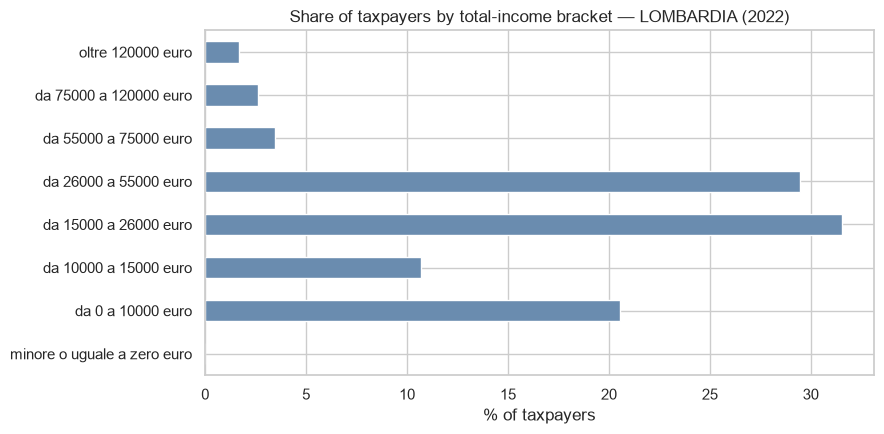

In [9]:
# Income-bracket composition (share of taxpayers per bracket) — frequency columns.
bracket_cols = [c for c in red_view.columns
                if c.startswith("Reddito complessivo") and c.endswith("Frequenza")]
short = (pd.Series(bracket_cols)
         .str.replace("Reddito complessivo ", "", regex=False)
         .str.replace(" - Frequenza", "", regex=False))
shares = red_view[bracket_cols].sum()
shares.index = short
shares = (shares / shares.sum() * 100)

ax = shares.plot(kind="barh", figsize=(9, 4.5), color="#6a8caf")
ax.set(title=f"Share of taxpayers by total-income bracket — {REGION or 'Italy'} ({YEAR})",
       xlabel="% of taxpayers"); plt.tight_layout(); plt.show()

## 6. Load & inspect administrative geometry

Read the national municipal boundaries, filter to the region early (the file is ~49 MB), and
reproject to the common CRS.

In [10]:
gdf_all = gpd.read_file(DATA_DIR / "limiti_comunali_2020.geojson")
print("Municipal polygons (national):", gdf_all.shape, "| CRS:", gdf_all.crs)
gdf_all[["nome_com", "nome_reg", "sig_pro", "belfiore", "istat"]].head(3)

Municipal polygons (national): (1506, 23) | CRS: EPSG:4326


,nome_com,nome_reg,sig_pro,belfiore,istat
0,PESCAROLO ED UNITI,LOMBARDIA,CR,G483,19069
1,INZAGO,LOMBARDIA,MI,E317,15114
2,FLERO,LOMBARDIA,BS,D634,17072


Polygons in scope: 1506


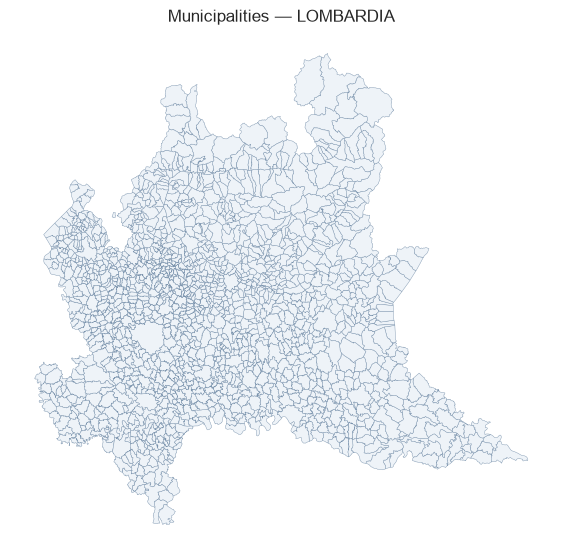

In [11]:
# The boundary file covers Lombardy only. Filter to REGION if it's present, else use all
# available geometry (so maps still render when REGION points elsewhere).
avail = set(gdf_all["nome_reg"].str.upper().dropna())
if REGION is not None and REGION.upper() in avail:
    muni = gdf_all[gdf_all["nome_reg"].str.upper() == REGION.upper()]
else:
    if REGION is not None:
        print(f"NOTE: '{REGION}' not in boundary file (covers {sorted(avail)}); mapping all available geometry.")
    muni = gdf_all
muni = muni.to_crs(epsg=COMMON_CRS).copy()
muni["belfiore"] = belfiore(muni["belfiore"])
print(f"Polygons in scope: {len(muni)}")

ax = muni.plot(figsize=(7, 7), facecolor="#eef3f8", edgecolor="#7a93ad", linewidth=0.3)
ax.set_axis_off(); ax.set_title(f"Municipalities — {REGION or 'Italy'}"); plt.show()

## 7. Spatial join — income onto municipalities

Merge income onto the polygons by the **Belfiore** code and render a choropleth of average income.

In [12]:
muni_inc = muni.merge(
    red_view[["belfiore", COL_COMUNE, COL_PROV, COL_TAXPAYERS, "avg_income", COL_INCOME]],
    on="belfiore", how="left")

matched = muni_inc["avg_income"].notna().mean() * 100
print(f"Income join coverage: {matched:.1f}% of polygons matched")

Income join coverage: 99.7% of polygons matched


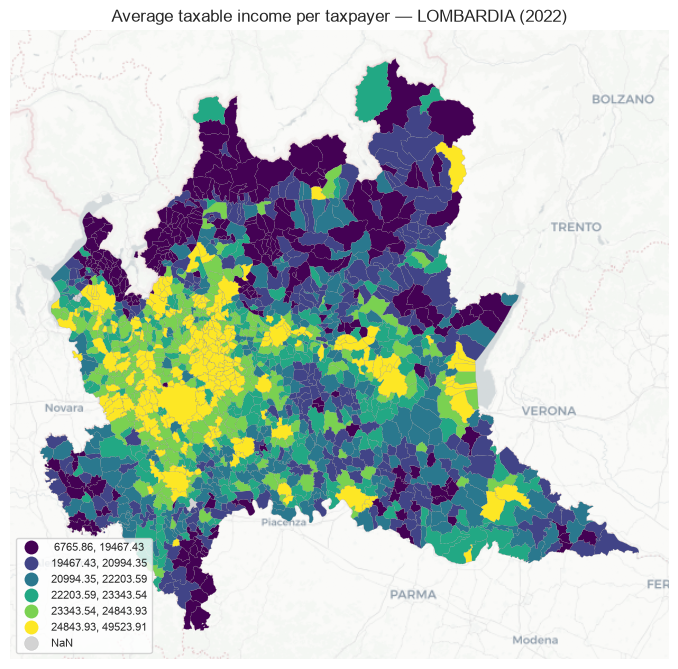

In [13]:
def choropleth(gdf, column, title, cmap="viridis", ax=None, scheme="quantiles", k=6):
    if ax is None:
        _, ax = plt.subplots(figsize=(8.5, 8.5))
    gdf.plot(column=column, cmap=cmap, scheme=scheme, k=k, legend=True,
             linewidth=0.1, edgecolor="grey", missing_kwds={"color": "lightgrey"},
             legend_kwds={"loc": "lower left", "fontsize": 8}, ax=ax)
    if ADD_BASEMAP and HAS_CTX:
        try:
            cx.add_basemap(ax, crs=gdf.crs, source=cx.providers.CartoDB.Positron, attribution=False)
        except Exception as e:
            print("basemap skipped:", e)
    ax.set_axis_off(); ax.set_title(title, fontsize=12)
    return ax

choropleth(muni_inc, "avg_income",
           f"Average taxable income per taxpayer — {REGION or 'Italy'} ({YEAR})",
           cmap="viridis")
plt.show()

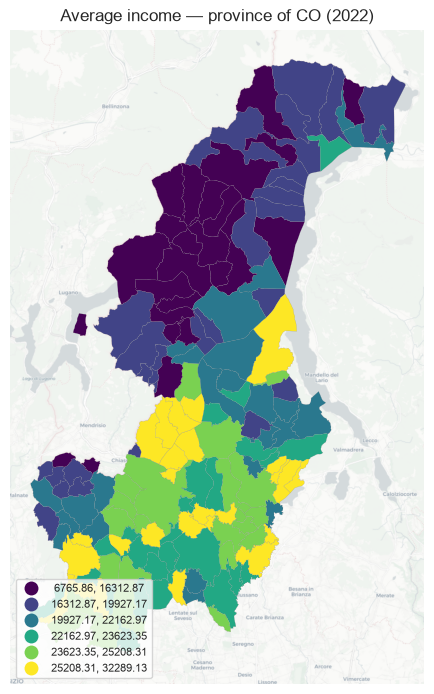

In [14]:
# Province zoom (e.g. Como) for detail.
if FOCUS_PROVINCE:
    focus = muni_inc[muni_inc[COL_PROV] == FOCUS_PROVINCE]
    if len(focus):
        ax = choropleth(focus, "avg_income",
                        f"Average income — province of {FOCUS_PROVINCE} ({YEAR})", cmap="viridis")
        plt.show()
    else:
        print(f"No municipalities for province {FOCUS_PROVINCE} in current scope.")

## 8. Real-estate prices (OMI)

Aggregate OMI sale quotations (€/m²) to the municipality via the Belfiore code (`Comune_amm`),
then map them.

In [15]:
# Mid-point sale price per row, then mean per municipality.
omi = omi.copy()
omi["price_m2"] = omi[["Compr_min", "Compr_max"]].mean(axis=1)
omi["rent_m2"]  = omi[["Loc_min", "Loc_max"]].mean(axis=1)
omi["belfiore"] = belfiore(omi["Comune_amm"])

omi_muni = (omi.groupby("belfiore")
              .agg(price_m2=("price_m2", "mean"),
                   rent_m2=("rent_m2", "mean"),
                   n_quotes=("price_m2", "size"))
              .reset_index())
print("Municipalities with OMI prices:", len(omi_muni))
omi_muni.sort_values("price_m2", ascending=False).head()

Municipalities with OMI prices: 1505


,belfiore,price_m2,rent_m2,n_quotes
742,E621,3030.000000,10.565714,35
250,B513,2985.000000,11.594444,10
844,F205,2781.172840,11.214300,486
164,B049,2674.444444,9.270000,45
1243,I633,2501.829268,11.403659,41


OMI price join coverage: 99.8% of polygons


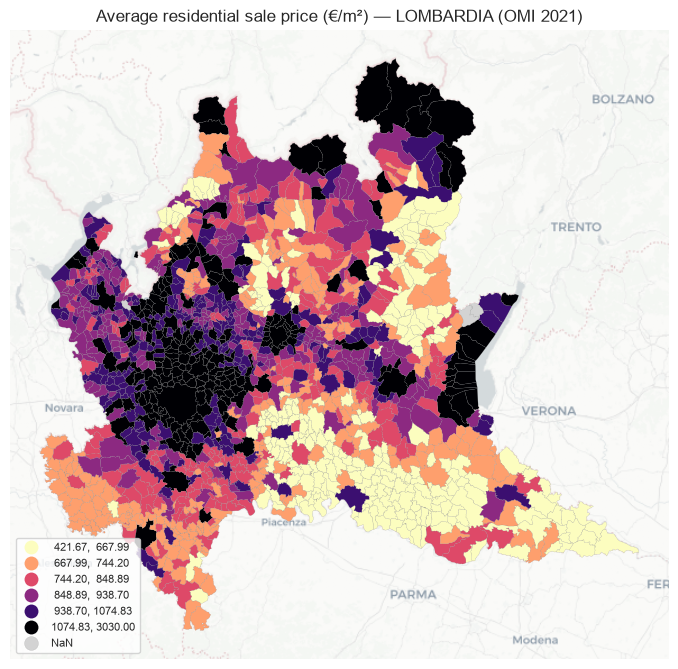

In [16]:
muni_omi = muni.merge(omi_muni, on="belfiore", how="left")
cov = muni_omi["price_m2"].notna().mean() * 100
print(f"OMI price join coverage: {cov:.1f}% of polygons")

choropleth(muni_omi, "price_m2",
           f"Average residential sale price (€/m²) — {REGION or 'Italy'} (OMI {OMI_YEAR})",
           cmap="magma_r")
plt.show()

## 9. Income vs. real-estate price

Combine the municipal income and price aggregates: how do they relate, and where is housing most
expensive relative to income?

1499 municipalities with both metrics | Pearson r = 0.45


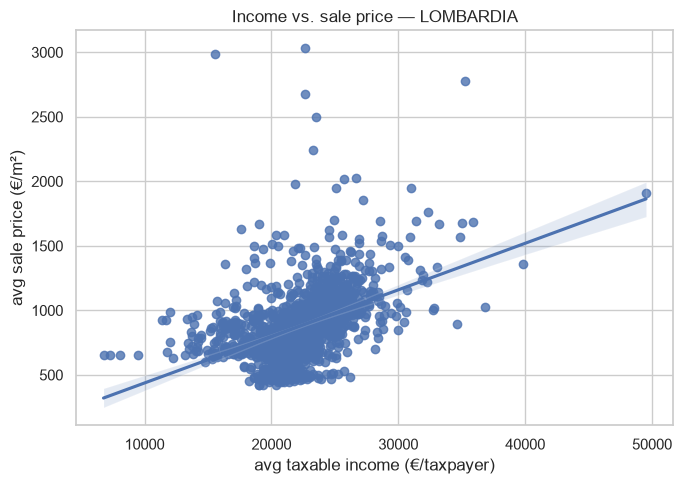

In [17]:
combo = (red_view[["belfiore", COL_COMUNE, COL_PROV, "avg_income"]]
         .merge(omi_muni[["belfiore", "price_m2", "rent_m2", "n_quotes"]], on="belfiore")
         .dropna(subset=["avg_income", "price_m2"]))
combo = combo[(combo["avg_income"] > 0) & (combo["price_m2"] > 0)]
r = combo["avg_income"].corr(combo["price_m2"])
print(f"{len(combo)} municipalities with both metrics | Pearson r = {r:.2f}")

ax = sns.regplot(data=combo, x="avg_income", y="price_m2")
ax.set(title=f"Income vs. sale price — {REGION or 'Italy'}",
       xlabel="avg taxable income (€/taxpayer)", ylabel="avg sale price (€/m²)")
ax.figure.set_size_inches(7, 5); plt.tight_layout(); plt.show()